# Assignment 1 - AcnEmphathize Dataset

**Course:** Natural Language Processing

**Group:** 12

    Guilherme Oliveira: 202204987
    Magda Costa: 202207036

---

# Index  <a name = "index"></a>
1. [Baseline models for AcnEmpathize](#bma)
    - [Baseline](#b)
    - [StopWords and Lemmatization](#sl)
    - [Load the dataset](#ld)
    - [Keep only the columns needed for baseline text classification](#kocnfbtc)
    - [Paper-aligned preprocessing](#pap)
    - [Train-test split](#tts)
    - [TF-IDF feature setup](#fs)
    - [Baseline models](#bm)
    - [Evaluation function](#ef)
    - [Train and compare all baseline models](#tcabm)
    - [Confusion matrices](cm)
2. [Baseline Conclusions](#bc)
    - [Comparison with the paper](#cwp)

---

# Baseline models for AcnEmpathize <a name = "bma"></a>

This notebook reproduces the **classical baseline setup** from the dataset's paper before moving to later variations.

We will:
1. load the dataset,
2. apply the same text preprocessing idea used in the paper,
3. build the same **non-transformer** models reported in the proof-of-concept section,
4. compare them under the same TF-IDF setup.

A small but important decision for this notebook: **all four classical models are treated as baselines**.  
So we will compare:
- Most Frequent Class
- Random
- Naive Bayes
- Logistic Regression



## 1. Baseline <a name = "b"></a>

The paper reports two levels of preprocessing:

- In the dataset construction step, posts were cleaned by removing newline characters and keeping only posts that contained **at least one alphabetical token**.
- In the dataset content analysis, the authors tokenized the posts, removed punctuation and stopwords, normalized case, and lemmatized tokens.
- In the proof-of-concept classification setup, the classical models used **TF-IDF with unigrams and `max_features=5000`**, with an **80/20 train-test split** and default scikit-learn settings for Naive Bayes and Logistic Regression.

So, for this notebook, we keep the pipeline aligned with that description:
- newline cleanup,
- filtering for at least one alphabetical token,
- lowercase,
- punctuation removal,
- stopword removal,
- lemmatization,
- TF-IDF unigram features with 5,000 features ( exactly as the paper approach)

In [19]:
# Core libraries
import re
import string
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import nltk

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## 2. StopWords and Lemmatization <a name = "sl"></a>

We use NLTK for English stopwords and WordNet lemmatization.  
The code below downloads the resources only if they are missing.

In [3]:

resources = {
    "tokenizers/punkt": "punkt",
    "corpora/stopwords": "stopwords",
    "corpora/wordnet": "wordnet",
    "corpora/omw-1.4": "omw-1.4",
}

for resource_path, resource_name in resources.items():
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(resource_name)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /Users/gjoli/nltk_data...
[nltk_data] Downloading package omw-1.4 to /Users/gjoli/nltk_data...


## 3. Load the dataset <a name = "ld"></a>

In [5]:
df = pd.read_csv("AcnEmpathize_dataset.csv")
df.head()


,url,title,post_id,user_id,text,quoted_id,reputation_number,reviews_count,following_count,followers_count,forums_count,conv_id,combined_empathy
0,https://www.acne.org/forums/10-emotional-and-psychological-effects-of-acne/389505-face-dysmorphia-can-you-guys-tell-...,"Face dysmorphia, can you guys tell me what's wrong with my face",3652542,781236,"Hello! I've been having a hard time, lingering a bit in depression this is why I'm making this post, I'm in my twe...",-1,0,0,0,0,1,1728,0
1,https://www.acne.org/forums/10-emotional-and-psychological-effects-of-acne/389505-face-dysmorphia-can-you-guys-tell-...,"Face dysmorphia, can you guys tell me what's wrong with my face",3654101,785370,"Hey man the pictures are not present, can you post them individually maybe?",-1,10,0,1,1,10,1728,0
2,https://www.acne.org/forums/10-emotional-and-psychological-effects-of-acne/388820-there-are-many-many-many-different...,There are many many many different opinions on what is considered beautiful,3646950,773875,There are many many many many many many many different opinions on what is considered beautiful. Maybe that could be...,-1,0,0,0,0,3,1722,0
3,https://www.acne.org/forums/10-emotional-and-psychological-effects-of-acne/388820-there-are-many-many-many-different...,There are many many many different opinions on what is considered beautiful,3647296,757568,Maybe in some African tribe my face scars would considered beautiful!,-1,114,0,9,3,439,1722,0
4,https://www.acne.org/forums/10-emotional-and-psychological-effects-of-acne/388820-there-are-many-many-many-different...,There are many many many different opinions on what is considered beautiful,3653501,517868,"None of those opinions consider acne to be beautiful. Sorry. I know some people use the word ""beauty"" to refer to wh...",3646950,7,0,0,0,7,1722,0


## 4. Keep only the columns needed for baseline text classification <a name = "kocnfbtc"></a>

For baseline, we will only need the text column and the associated empathy label

In [8]:
baseline_df = df[['text', 'combined_empathy']].copy()
baseline_df = baseline_df.rename(columns={'combined_empathy': 'label'})
baseline_df.head()

,text,label
0,"Hello! I've been having a hard time, lingering a bit in depression this is why I'm making this post, I'm in my twe...",0
1,"Hey man the pictures are not present, can you post them individually maybe?",0
2,There are many many many many many many many different opinions on what is considered beautiful. Maybe that could be...,0
3,Maybe in some African tribe my face scars would considered beautiful!,0
4,"None of those opinions consider acne to be beautiful. Sorry. I know some people use the word ""beauty"" to refer to wh...",0


## 5. Paper-aligned preprocessing <a name = "pap"></a>

This step follows the paper as closely as possible with the information explicitly described there.

### What we do
- replace newline characters with spaces,
- keep only posts that contain at least one alphabetical token,
- lowercase,
- remove punctuation,
- tokenize,
- remove stopwords,
- lemmatize,
- join tokens back into a clean string for TF-IDF.

> Important note

The paper does not provide the exact tokenizer or exact lemmatization implementation used in code.  
So the **design choices** below are faithful to the paper’s description, while the exact implementation is our reproducible approximation.

In [9]:
alphabetic_pattern = re.compile(r"[A-Za-z]+")

def remove_newlines(text: str) -> str:
    return re.sub(r"[\r\n]+", " ", str(text)).strip()

def has_alphabetical_token(text: str) -> bool:
    return bool(alphabetic_pattern.search(text))

def preprocess_text(text: str) -> str:
    # 1) remove newlines
    text = remove_newlines(text)

    # 2) lowercase
    text = text.lower()

    # 3) keep alphabetic tokens only
    tokens = re.findall(r"[a-z]+", text)

    # 4) remove stopwords + lemmatize
    cleaned_tokens = []
    for tok in tokens:
        if tok in STOPWORDS:
            continue
        lemma = LEMMATIZER.lemmatize(tok)
        if lemma:
            cleaned_tokens.append(lemma)

    return " ".join(cleaned_tokens)

In [10]:
# Dataset-level cleanup matching the paper's filtering idea
baseline_df["text_no_newlines"] = baseline_df["text"].apply(remove_newlines)
baseline_df = baseline_df[baseline_df["text_no_newlines"].apply(has_alphabetical_token)].copy()

# Text actually used for classical baselines
baseline_df["text_preprocessed"] = baseline_df["text_no_newlines"].apply(preprocess_text)

# Some rows may become empty after stopword removal / normalization
baseline_df = baseline_df[baseline_df["text_preprocessed"].str.strip().ne("")].copy()

print("Dataset shape after preprocessing/filtering:", baseline_df.shape)
baseline_df[["text", "text_preprocessed", "label"]].head(10)

Dataset shape after preprocessing/filtering: (12199, 4)


,text,text_preprocessed,label
0,"Hello! I've been having a hard time, lingering a bit in depression this is why I'm making this post, I'm in my twe...",hello hard time lingering bit depression making post twenty summer holiday spent spain someone met told hey skin loo...,0
1,"Hey man the pictures are not present, can you post them individually maybe?",hey man picture present post individually maybe,0
2,There are many many many many many many many different opinions on what is considered beautiful. Maybe that could be...,many many many many many many many different opinion considered beautiful maybe could helpful try remember,0
3,Maybe in some African tribe my face scars would considered beautiful!,maybe african tribe face scar would considered beautiful,0
4,"None of those opinions consider acne to be beautiful. Sorry. I know some people use the word ""beauty"" to refer to wh...",none opinion consider acne beautiful sorry know people use word beauty refer inside think clear referring aesthetic ...,0
5,Why some people dont have body acne and face acne when eat white rice and why some people have? Some people do the v...,people dont body acne face acne eat white rice people people vegan candida diet life style eating non starched veget...,0
6,This is unfair,unfair,0
7,Have a look at medical medium run by Anthony William. Basically people jave toxicity which is pssed down from parent...,look medical medium run anthony william basically people jave toxicity pssed parent child form unhealthy gut bacteri...,0
8,"Acne is more likely if you consume foods and drinks like soda, white bread, white rice, and cake. Sugar and carbohyd...",acne likely consume food drink like soda white bread white rice cake sugar carbohydrate food enter bloodstream quick...,0
9,You have to have the genetic predisposition for acne before any external factors come into play. That's why person A...,genetic predisposition acne external factor come play person eat whatever want without getting acne whereas person b...,0


## 6. Train-test split <a name = "tts"></a>


The paper uses a **random 80/20 split** for all posts.

Here we also use:
- `test_size=0.20`
- `stratify=y` to preserve class balance in the split
- `random_state=42` for reproducibility

The random seed is a reproducibility choice from this notebook.  
The paper states a random split, but does not specify a seed in the text.

In [11]:
X = baseline_df["text_preprocessed"]
y = baseline_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))
print("\nTest distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

Train size: 9759
Test size : 2440

Train distribution:
label
0    0.756
1    0.244
Name: proportion, dtype: float64

Test distribution:
label
0    0.7561
1    0.2439
Name: proportion, dtype: float64


## 7. TF-IDF feature setup <a name = "fs"></a>

For the classical models, the paper uses:
- **TF-IDF**
- **unigrams**
- **maximum number of features = 5,000**

We keep exactly that feature configuration here.

In [12]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1)
)

# Fit only on training data to avoid leakage
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape :", X_test_tfidf.shape)

Train TF-IDF shape: (9759, 5000)
Test TF-IDF shape : (2440, 5000)


## 8. Baseline models <a name = "bm"></a>

These are the **non-transformer models** reported in the paper:

- Most Frequent Class
- Random
- Naive Bayes
- Logistic Regression

We use default scikit-learn settings for Naive Bayes and Logistic Regression, matching the paper’s description for unspecified parameters.

In [13]:
models = {
    "Most Frequent Class": DummyClassifier(strategy="most_frequent"),
    "Random": DummyClassifier(strategy="uniform", random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

## 9. Evaluation function <a name = "ef"></a>

The paper reports:
- accuracy,
- precision,
- recall,
- F1

For **each class separately**.

Because the dataset is imbalanced, this is more informative than accuracy alone.  
We also store macro-F1, macro-precision, and macro-recall to make later comparisons easier.

In [14]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1], zero_division=0
    )

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    result = {
        "model": model_name,
        "accuracy": acc,
        "precision_no_empathy": precision[0],
        "recall_no_empathy": recall[0],
        "f1_no_empathy": f1[0],
        "precision_empathy": precision[1],
        "recall_empathy": recall[1],
        "f1_empathy": f1[1],
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

    return result, y_pred

## 10. Train and compare all baseline models <a name = "tcabm"></a>

In [15]:
results = []
predictions = {}

for model_name, model in models.items():
    result, y_pred = evaluate_model(
        model=model,
        X_train=X_train_tfidf,
        y_train=y_train,
        X_test=X_test_tfidf,
        y_test=y_test,
        model_name=model_name
    )
    results.append(result)
    predictions[model_name] = y_pred

results_df = pd.DataFrame(results).sort_values(
    by=["macro_f1", "f1_empathy", "accuracy"],
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,model,accuracy,precision_no_empathy,recall_no_empathy,f1_no_empathy,precision_empathy,recall_empathy,f1_empathy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Logistic Regression,0.8242,0.8321,0.9615,0.8921,0.7695,0.3983,0.5249,0.8008,0.6799,0.7085,0.8026
1,Random,0.4865,0.7376,0.4981,0.5946,0.2245,0.4504,0.2996,0.4810,0.4743,0.4471,0.5227
2,Naive Bayes,0.7586,0.7584,0.9989,0.8622,0.8000,0.0134,0.0264,0.7792,0.5062,0.4443,0.6584
3,Most Frequent Class,0.7561,0.7561,1.0000,0.8611,0.0000,0.0000,0.0000,0.3781,0.5000,0.4306,0.6512


At this point, do **not** look only at accuracy.

For this task, the most important things to inspect are:
- `f1_empathy`, because empathy is the minority class,
- `macro_f1`, because it gives both classes equal importance,
- the precision/recall trade-off for the empathy class.

A model can look good on accuracy while still missing many empathetic posts.

In [16]:
# A cleaner summary table for discussion
summary_cols = [
    "model",
    "accuracy",
    "macro_f1",
    "precision_empathy",
    "recall_empathy",
    "f1_empathy",
    "precision_no_empathy",
    "recall_no_empathy",
    "f1_no_empathy",
]

results_df[summary_cols].round(4)

,model,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy
0,Logistic Regression,0.8242,0.7085,0.7695,0.3983,0.5249,0.8321,0.9615,0.8921
1,Random,0.4865,0.4471,0.2245,0.4504,0.2996,0.7376,0.4981,0.5946
2,Naive Bayes,0.7586,0.4443,0.8000,0.0134,0.0264,0.7584,0.9989,0.8622
3,Most Frequent Class,0.7561,0.4306,0.0000,0.0000,0.0000,0.7561,1.0000,0.8611


## 11. Confusion matrices <a name = "cm"></a>

Confusion matrices help us see **what kind of mistake** each model is making.

For this problem, a frequent issue is:
- predicting `No Empathy` too often,
- which hurts recall on the `Empathy` class.

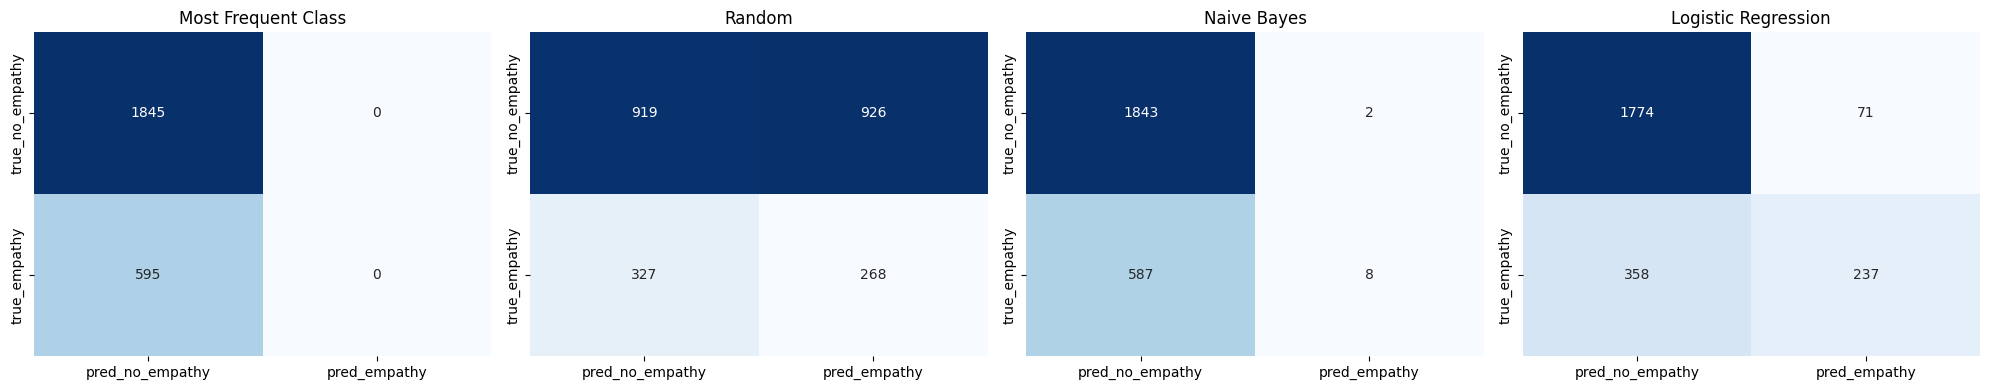

In [20]:
n_models = len(predictions)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

# If only one model, make axes iterable
if n_models == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["pred_no_empathy", "pred_empathy"],
        yticklabels=["true_no_empathy", "true_empathy"]
    )
    
    ax.set_title(model_name)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [21]:
results_path = Path("results/baseline_results.csv")
results_df.to_csv(results_path, index=False)

print(f"Saved results to: {results_path.resolve()}")

Saved results to: /Users/gjoli/Desktop/uni/2_semester/NLP/assignment1/results/baseline_results.csv


---

# Baseline Conclusions <a name = "bc"></a>

The results clearly show a strong class imbalance problem. The dataset is dominated by no_empathy, which causes most models to favor this class and ignore empathy.

- Most Frequent Class achieves high accuracy (~0.75) but completely fails to detect empathy (recall = 0). This confirms that accuracy alone is misleading in this task.

- Random model behaves as expected (Macro-F1 ≈ 0.45), validating that the evaluation setup is correct.

- Naive Bayes performs poorly for the empathy class:

    - Very high precision (0.80) but almost zero recall (0.01)

    -  It predicts almost everything as no_empathy, missing nearly all true empathy cases
        → This shows a strong bias toward the majority class.

- Logistic Regression is the best-performing model:

    - Accuracy: 0.82, Macro-F1: 0.71

    - It achieves a better balance between precision and recall, and is the only model that meaningfully detects empathy

    - However, recall is still low (≈ 0.40), meaning many empathy cases are still missed

From the confusion matrices, the main issue is clear:
→ high number of false negatives (missed empathy) across all models.



## Comparison with the paper <a name = "cwp"></a>

- These results match the behavior reported in the paper:

- Classical models with TF-IDF:

    - Perform well on the majority class

    - Struggle significantly with the minority (empathy) class

    - Logistic Regression is typically the strongest classical baseline, which is exactly what we observe